# 02. A1 Feasibility — SHAP × 債券アトリビューション

**目的**: 整備済データで「非線形寄与（SHAP-線形 OLS のギャップ）」がどの程度の量・どこに偏るかを概算する。  
GO/NO-GO 判断材料: 非線形寄与が金利系 / クレジット系 / ボラ系のどこに集中するか。

**設計**
1. 従属変数 (3 種を並走)
   - `Robeco IG MultiFactor` 月次リターン（long-short factor、1994-2025）
   - `ΔBAA10Y` IG クレジットスプレッド変化（1986-現在の長期）
   - `ΔBAMLC0A0CM` BAML IG OAS 変化（短期 2023-）
2. 説明変数 (Δ化、月次変化)
   - 金利系: `ΔDGS10`, `Δslope (DGS10-DGS2)`, `ΔDGS3MO`
   - クレジット系: `ΔBAA10Y` (target が Robeco / BAML のときのみ), `ebp`, `NFCI`
   - ボラ系: `ΔVIX`, `ΔMOVE`
   - マクロ: `ΔUNRATE`, `INDPRO yoy`
3. モデル
   - 線形 OLS （HAC SE）
   - LightGBM / XGBoost（5-fold time-series CV）
   - SHAP TreeExplainer で global importance と interaction
4. 非線形寄与の定量化
   - **R² gap**: tree_R² - OLS_R²
   - **SHAP interaction share**: |interaction_off_diag| / |SHAP_total|

**caveat**
- 月次・全期間で n が 300 ヶ月程度。tree モデルは regularization 不足だと overfit するので CV で R² を見る
- Robeco は再配布禁止（[[data-source-caveats]]）

## 1. Imports & データ準備

In [1]:
from __future__ import annotations

import warnings

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
import statsmodels.api as sm
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score

from fi_research.data.robeco import load_robeco_credit_factors
from fi_research.paths import REPO_ROOT, ensure_dir

warnings.filterwarnings("ignore")
np.random.seed(42)

RESULTS_DIR = ensure_dir(REPO_ROOT / "projects" / "00_exploration" / "results" / "02_a1_shap_sketch")
MONTHLY_PANEL = REPO_ROOT / "projects" / "00_exploration" / "results" / "01_macro_credit_state" / "monthly_panel.parquet"
monthly = pd.read_parquet(MONTHLY_PANEL)
print("monthly panel:", monthly.shape, monthly.index.min().date(), "->", monthly.index.max().date())

ig = load_robeco_credit_factors("IG").set_index("date").sort_index()
ig.index = ig.index.to_period("M").to_timestamp("M")

monthly panel: (2058, 78) 1854-12-31 -> 2026-05-31


### 1a. 説明変数の組み立て（Δ 化 + マクロ yoy）

In [2]:
X = pd.DataFrame(index=monthly.index)
X["d_dgs10"] = monthly["DGS10"].diff()
X["d_dgs3mo"] = monthly["DGS3MO"].diff()
X["d_slope_10y_2y"] = (monthly["DGS10"] - monthly["DGS2"]).diff()
X["d_curv_2_5_10"] = (2 * monthly["DGS5"] - monthly["DGS2"] - monthly["DGS10"]).diff()
X["d_baa10y"] = monthly["BAA10Y"].diff()
X["ebp"] = monthly["ebp"]
X["NFCI"] = monthly["NFCI"]
X["d_vix"] = monthly["VIXCLS"].diff()
X["d_move"] = monthly["MOVE"].diff()
X["d_unrate"] = monthly["UNRATE"].diff()
X["indpro_yoy"] = monthly["INDPRO"].pct_change(12) * 100
X["d_ofr_fsi"] = monthly["ofr_ofr_fsi"].diff()
X["d_dff"] = monthly["DFF"].diff()

Y = pd.DataFrame(index=monthly.index)
Y["robeco_ig_mf"] = ig["MultiFactor"].reindex(monthly.index)
Y["d_baa10y"] = monthly["BAA10Y"].diff()
Y["d_baml_ig_oas"] = monthly["BAMLC0A0CM"].diff()

print("X cols:", list(X.columns))
print("Y cols:", list(Y.columns))

X cols: ['d_dgs10', 'd_dgs3mo', 'd_slope_10y_2y', 'd_curv_2_5_10', 'd_baa10y', 'ebp', 'NFCI', 'd_vix', 'd_move', 'd_unrate', 'indpro_yoy', 'd_ofr_fsi', 'd_dff']
Y cols: ['robeco_ig_mf', 'd_baa10y', 'd_baml_ig_oas']


## 2. 比較フレームワーク: 線形 OLS vs Tree (CV) vs SHAP

**注意**: 従属変数が `d_baa10y` の場合、説明変数からも `d_baa10y` を抜く（leakage 回避）。

In [3]:
from sklearn.linear_model import LinearRegression


def prep(target: str, X: pd.DataFrame, Y: pd.DataFrame) -> tuple[pd.DataFrame, pd.Series]:
    Xc = X.copy()
    if target in Xc.columns:
        Xc = Xc.drop(columns=[target])
    df = pd.concat([Y[target].rename("y"), Xc], axis=1).dropna()
    return df.drop(columns="y"), df["y"]


def cv_oof_r2(estimator_factory, Xd: pd.DataFrame, yd: pd.Series, n_splits: int = 5):
    """OOF R² + mean in-sample R² under TimeSeriesSplit. Same splits for OLS and Tree."""
    tscv = TimeSeriesSplit(n_splits=n_splits)
    oof = np.full(len(yd), np.nan)
    in_r2 = []
    for tr, te in tscv.split(Xd):
        m = estimator_factory()
        m.fit(Xd.iloc[tr], yd.iloc[tr])
        oof[te] = m.predict(Xd.iloc[te])
        in_r2.append(r2_score(yd.iloc[tr], m.predict(Xd.iloc[tr])))
    mask = ~np.isnan(oof)
    return r2_score(yd.iloc[mask], oof[mask]), float(np.mean(in_r2))


def make_ols():
    return LinearRegression()


def make_lgb():
    return lgb.LGBMRegressor(
        n_estimators=400, learning_rate=0.03, num_leaves=15,
        min_child_samples=10, reg_lambda=1.0, random_state=42, verbose=-1,
    )


def make_xgb():
    return xgb.XGBRegressor(
        n_estimators=400, learning_rate=0.03, max_depth=3,
        reg_lambda=1.0, random_state=42, verbosity=0,
    )


def fit_full_tree(Xd: pd.DataFrame, yd: pd.Series, kind: str = "lgb"):
    m = make_lgb() if kind == "lgb" else make_xgb()
    m.fit(Xd, yd)
    return m


## 3. 3 ターゲット × OLS / LightGBM / XGBoost で R² 比較

In [4]:
targets = ["robeco_ig_mf", "d_baa10y", "d_baml_ig_oas"]
rows = []
models = {}
data = {}
for tgt in targets:
    Xd, yd = prep(tgt, X, Y)
    data[tgt] = (Xd, yd)
    if len(yd) < 30:
        rows.append({"target": tgt, "n": len(yd)})
        continue
    ols_oof, ols_in = cv_oof_r2(make_ols, Xd, yd)
    lgb_oof, lgb_in = cv_oof_r2(make_lgb, Xd, yd)
    xgb_oof, xgb_in = cv_oof_r2(make_xgb, Xd, yd)
    models[tgt] = {"lgb": fit_full_tree(Xd, yd, "lgb"), "xgb": fit_full_tree(Xd, yd, "xgb")}
    rows.append({
        "target": tgt, "n": len(yd),
        "OLS_oof": round(ols_oof, 3),
        "OLS_in": round(ols_in, 3),
        "LGB_oof": round(lgb_oof, 3),
        "LGB_in": round(lgb_in, 3),
        "XGB_oof": round(xgb_oof, 3),
        "R2gap_LGB_OLS": round(lgb_oof - ols_oof, 3),
        "R2gap_XGB_OLS": round(xgb_oof - ols_oof, 3),
    })
summary_r2 = pd.DataFrame(rows).set_index("target")
print(summary_r2.to_string())
summary_r2.to_csv(RESULTS_DIR / "r2_summary.csv")


                 n  OLS_oof  OLS_in  LGB_oof  LGB_in  XGB_oof  R2gap_LGB_OLS  R2gap_XGB_OLS
target                                                                                     
robeco_ig_mf   275    0.626   0.852    0.282   0.966    0.382         -0.345         -0.244
d_baa10y       279    0.244   0.727    0.263   0.952    0.323          0.019          0.079
d_baml_ig_oas   33    0.011   0.970    0.108   0.322    0.207          0.096          0.196


**読み方**: `OLS_oof` と `LGB_oof / XGB_oof` を **同じ TimeSeriesSplit (5-fold)** で測る fair 比較。`R2gap_LGB_OLS = LGB_oof − OLS_oof` が「out-of-fold で測った非線形寄与」の主要指標。

- gap が +0.05 以上 → 線形では捉えられない構造あり (A1 シグナル)
- gap が ~0 や負 → 月次・全期間データでは tree モデルの汎化メリットが出ない (A1 NO-GO 寄り)
- `OLS_in − OLS_oof` が大きい → 線形でも汎化が弱い (regime shift 等)
- `LGB_in − LGB_oof` が大きい → tree が overfit している

## 4. SHAP global importance — 3 ターゲット


In [5]:
def shap_importance(model, Xd: pd.DataFrame) -> pd.Series:
    explainer = shap.TreeExplainer(model)
    sv = explainer.shap_values(Xd)
    imp = pd.Series(np.abs(sv).mean(axis=0), index=Xd.columns, name="mean_abs_shap")
    return imp.sort_values(ascending=False)

shap_tables = {}
for tgt in targets:
    if tgt not in models:
        continue
    Xd, yd = data[tgt]
    imp = shap_importance(models[tgt]["lgb"], Xd)
    shap_tables[tgt] = imp
    print(f"=== SHAP global importance — {tgt} (n={len(yd)}) ===")
    print(imp.round(4).to_string())
    print()
    imp.to_csv(RESULTS_DIR / f"shap_importance_{tgt}.csv")

=== SHAP global importance — robeco_ig_mf (n=275) ===
d_baa10y          0.0046
d_ofr_fsi         0.0024
indpro_yoy        0.0007
d_dff             0.0007
NFCI              0.0007
ebp               0.0007
d_slope_10y_2y    0.0006
d_vix             0.0006
d_curv_2_5_10     0.0006
d_move            0.0005
d_dgs3mo          0.0003
d_dgs10           0.0002
d_unrate          0.0002



=== SHAP global importance — d_baa10y (n=279) ===
d_ofr_fsi         0.0701
d_curv_2_5_10     0.0455
d_dgs10           0.0209
d_vix             0.0174
indpro_yoy        0.0169
ebp               0.0167
d_dff             0.0129
NFCI              0.0105
d_move            0.0101
d_dgs3mo          0.0086
d_unrate          0.0064
d_slope_10y_2y    0.0049

=== SHAP global importance — d_baml_ig_oas (n=33) ===
d_baa10y          0.0400
d_dgs3mo          0.0136
d_move            0.0119
d_ofr_fsi         0.0117
d_curv_2_5_10     0.0092
indpro_yoy        0.0089
NFCI              0.0078
d_slope_10y_2y    0.0066
d_vix             0.0066
d_dgs10           0.0065
ebp               0.0004
d_unrate          0.0000
d_dff             0.0000



## 5. SHAP main vs interaction

TreeExplainer の `shap_interaction_values` を使い、対角成分（main effect）と非対角成分（pairwise interaction）に分解。  
**`interaction_share = |off_diag| / |total|`** が大きいほど「非線形寄与（変数間の相互作用）」が強い。

In [6]:
def shap_interaction_share(model, Xd: pd.DataFrame) -> dict:
    explainer = shap.TreeExplainer(model)
    inter = explainer.shap_interaction_values(Xd)  # (n, p, p)
    if isinstance(inter, list):
        inter = inter[0]
    p = inter.shape[1]
    main_abs = np.abs(np.diagonal(inter, axis1=1, axis2=2)).sum()
    off_abs = (np.abs(inter).sum() - np.abs(np.diagonal(inter, axis1=1, axis2=2)).sum())
    total = main_abs + off_abs
    # Pairwise heatmap (sum over samples of |off-diag|)
    pair = np.abs(inter).sum(axis=0)
    np.fill_diagonal(pair, 0)
    return {
        "main_abs_share": main_abs / total,
        "interaction_abs_share": off_abs / total,
        "pair_heat": pd.DataFrame(pair, index=Xd.columns, columns=Xd.columns),
    }

share_rows = []
pair_heats = {}
for tgt in targets:
    if tgt not in models:
        continue
    Xd, _ = data[tgt]
    res = shap_interaction_share(models[tgt]["lgb"], Xd)
    pair_heats[tgt] = res["pair_heat"]
    share_rows.append({"target": tgt, "main_share": round(res["main_abs_share"], 3), "interaction_share": round(res["interaction_abs_share"], 3)})
share_df = pd.DataFrame(share_rows).set_index("target")
print("=== SHAP main vs interaction shares ===")
print(share_df.to_string())
share_df.to_csv(RESULTS_DIR / "shap_main_vs_interaction.csv")

=== SHAP main vs interaction shares ===
               main_share  interaction_share
target                                      
robeco_ig_mf        0.631              0.369
d_baa10y            0.573              0.427
d_baml_ig_oas       0.818              0.182


## 6. 可視化

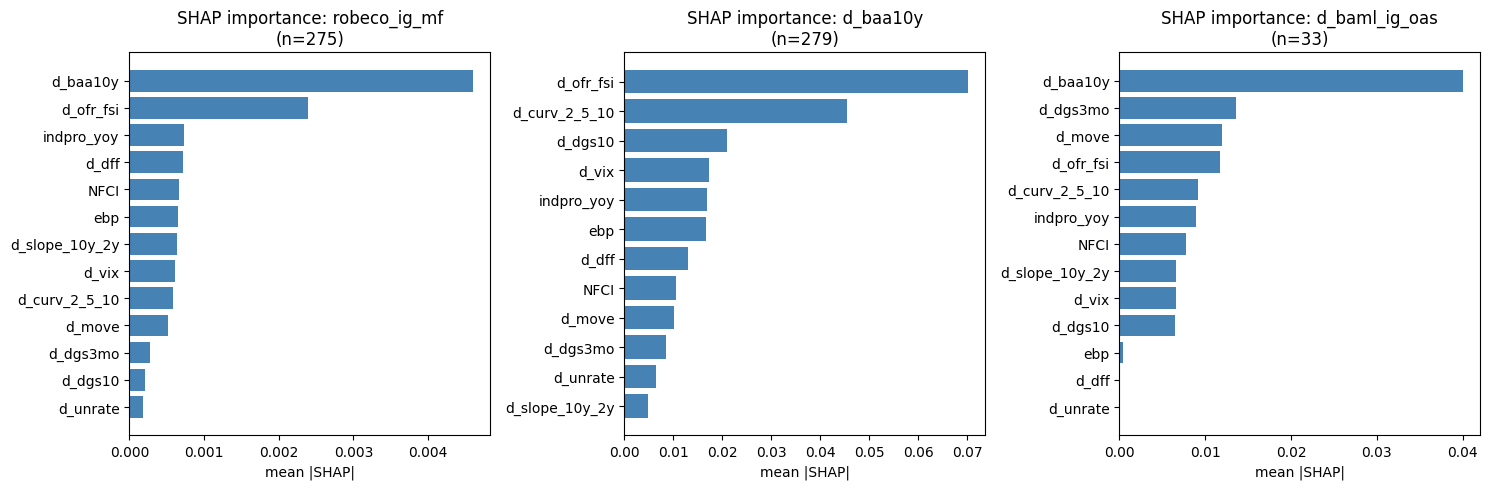

In [7]:
n_active = sum(1 for t in targets if t in shap_tables)
fig, axes = plt.subplots(1, n_active, figsize=(5 * n_active, 5), sharey=False)
if n_active == 1:
    axes = [axes]
for ax, tgt in zip(axes, [t for t in targets if t in shap_tables]):
    imp = shap_tables[tgt].sort_values()
    ax.barh(imp.index, imp.values, color="steelblue")
    ax.set_title(f"SHAP importance: {tgt}\n(n={len(data[tgt][1])})")
    ax.set_xlabel("mean |SHAP|")
fig.tight_layout()
fig.savefig(RESULTS_DIR / "shap_importance.png", dpi=150, bbox_inches="tight")
plt.show()

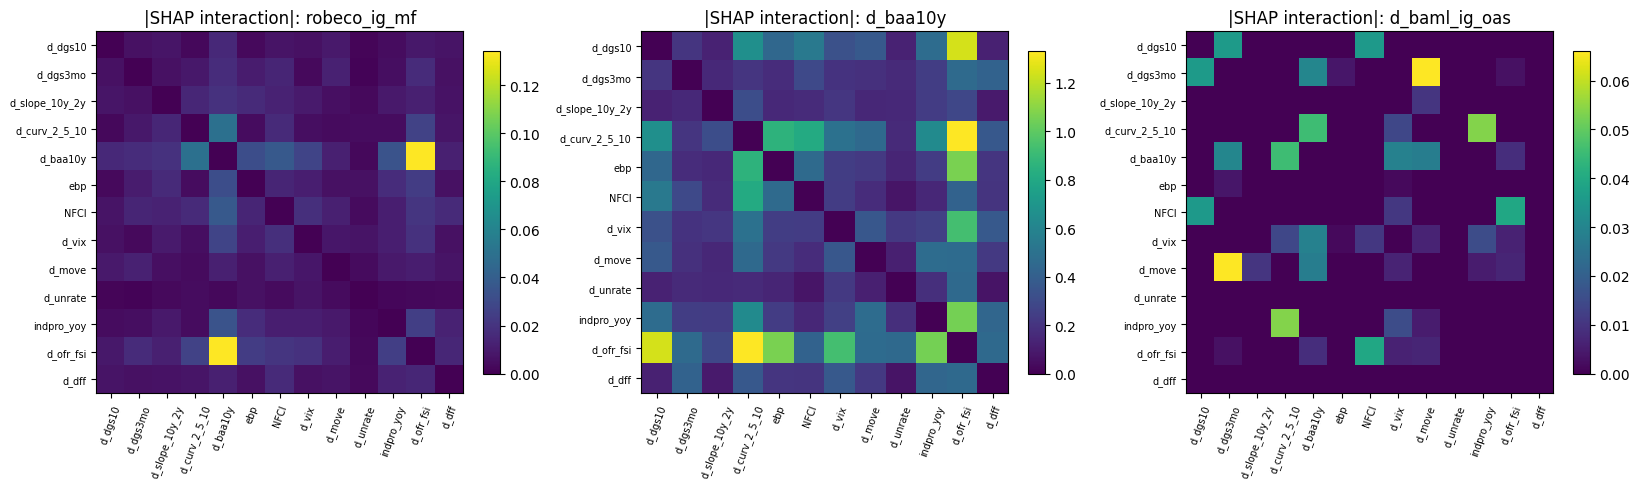

In [8]:
n_active = sum(1 for t in targets if t in pair_heats)
fig, axes = plt.subplots(1, n_active, figsize=(5.5 * n_active, 5))
if n_active == 1:
    axes = [axes]
for ax, tgt in zip(axes, [t for t in targets if t in pair_heats]):
    M = pair_heats[tgt]
    im = ax.imshow(M.values, cmap="viridis", aspect="auto")
    ax.set_xticks(range(len(M.columns)))
    ax.set_yticks(range(len(M.index)))
    ax.set_xticklabels(M.columns, rotation=70, fontsize=7)
    ax.set_yticklabels(M.index, fontsize=7)
    ax.set_title(f"|SHAP interaction|: {tgt}")
    fig.colorbar(im, ax=ax, fraction=0.04)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "shap_interaction_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. 非線形寄与のカテゴリ別集計

SHAP importance をカテゴリ（金利系 / クレジット系 / ボラ系 / マクロ）に集計し、A1 のテーマで強調すべき領域を特定する。

In [9]:
categories = {
    "rates": ["d_dgs10", "d_dgs3mo", "d_slope_10y_2y", "d_curv_2_5_10", "d_dff"],
    "credit": ["d_baa10y", "ebp", "NFCI", "d_ofr_fsi"],
    "vol": ["d_vix", "d_move"],
    "macro": ["d_unrate", "indpro_yoy"],
}

cat_rows = []
for tgt, imp in shap_tables.items():
    row = {"target": tgt}
    total = imp.sum()
    for cat, cols in categories.items():
        row[cat] = round(imp.reindex([c for c in cols if c in imp.index]).sum() / total, 3) if total > 0 else np.nan
    cat_rows.append(row)
cat_df = pd.DataFrame(cat_rows).set_index("target")
print("=== SHAP importance share by category ===")
print(cat_df.to_string())
cat_df.to_csv(RESULTS_DIR / "shap_category_share.csv")

=== SHAP importance share by category ===
               rates  credit    vol  macro
target                                    
robeco_ig_mf   0.191   0.650  0.088  0.071
d_baa10y       0.385   0.404  0.114  0.097
d_baml_ig_oas  0.291   0.486  0.150  0.072


## 8. GO / NO-GO 判定

| 観点 | 判定軸 | 参照セル |
|---|---|---|
| 非線形寄与の総量 | OOF R² gap が +0.05 以上か | § 3 |
| 相互作用の比率 | interaction_share > 30% か | § 5 |
| 偏在領域 | 金利・クレジット・ボラのどこに集中するか | § 7 |
| 統計力 | n が tree モデルとして最低 100 ヶ月以上か | § 3 (n) |

**先取りのチェックリスト**
- R² gap が小さい場合: A1 の「非線形性が価値を生む」主張は弱い → A2 に寄せる or MBS/Callable に対象を絞る必要
- R² gap が大きい場合: A1 GO。SHAP の偏在カテゴリが論文の焦点になる（例: ボラ系に偏れば MOVE/VIX × OAS の非線形相互作用が主題）

## 9. 次の一手

- 03 の結果と並べて A1 / A2 の最終収束（research_themes.md を更新）
- A1 を進める場合、(1) Robeco IG/HY 全 5 ファクター × SHAP、(2) MBS / Callable の代理データを探す、(3) interaction 上位ペアの dependence plot で深掘り